# RideWise - Feature Engineering
 - Transform clean riders and trips data that can help have a better churn prediction
 - Engineer 20 + features 
 - (1) RFM framework + (2) Behavioral + (3) Temporal signals

#### Step 1 - Setup 

In [5]:
## Setup & import libraries

import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.2)


# define the data paths
DATA_PROCESSED = os.path.join("..", "data", "processed")

# load the datasets
riders = pd.read_csv(os.path.join(DATA_PROCESSED, "riders_clean.csv"), parse_dates=["signup_date"])
drivers = pd.read_csv(os.path.join(DATA_PROCESSED, "drivers_clean.csv"))
trips = pd.read_csv(os.path.join(DATA_PROCESSED, "trips_clean.csv"), parse_dates=["pickup_time", "dropoff_time"])
sessions = pd.read_csv(os.path.join(DATA_PROCESSED, "sessions_clean.csv"), parse_dates=["session_time"])


# Reference date
#- In real Ml deployment settings, reference_date is mean NOW,
# we calculate "days since last trip"
reference_date = trips["pickup_time"].max()


In [6]:
trips.head()
print(trips.dtypes)

trip_id                     object
user_id                     object
driver_id                   object
fare                       float64
surge_multiplier           float64
tip                        float64
payment_type                object
pickup_time         datetime64[ns]
dropoff_time        datetime64[ns]
pickup_lat                 float64
pickup_lng                 float64
dropoff_lat                float64
dropoff_lng                float64
weather                     object
city                        object
loyalty_status              object
trip_duration              float64
total_revenue              float64
hour_of_day                  int64
day_of_week                 object
dtype: object


### Step 1a - Engineering some Rider Features
- 1- Eligible Riders (AKA active) : check for rider who had atleast 1 trips
- 2 - check for riders who had trips in the last 60days 

In [7]:
# Set the user_id in trips
riders_with_trips = set(trips["user_id"])

# check for the account age in days (How old is this rider's account?)
riders["account_age_days"] = (
    reference_date - riders["signup_date"]
).dt.days

# Elgible riders (1 - Account >=60 days and 
# 2 - at least 1 trip)
eligible = riders[
    riders["user_id"].isin(riders_with_trips) &
    (riders["account_age_days"] >= 60)
][["user_id", "churned"]].copy()



### Step 1b - Engineering RFM Features

- RFM -- Recency, Frequency , Monetary(Revenue metrics)

In [8]:
# Recency: How long since the last trip?
# group 1: last trip date
last_trip = (
    trips.groupby("user_id")["pickup_time"].max()
    .reset_index(name="last_trip")

)

# group 2: last session date on the app
last_session = (
    sessions.groupby("rider_id")["session_time"].max()
    .reset_index().rename(columns={"session_time": "last_session", "rider_id": "user_id"})
)

# Recency : combination of group 1 and group 2
recency = eligible[["user_id"]].merge(last_trip, on="user_id", how="left").merge(
    last_session, on="user_id", how="left"
)

# calculaye the recency features 
recency["days_since_last_trip"] = (reference_date - recency["last_trip"]).dt.days.fillna(999)
recency["days_since_last_session"] = (reference_date - recency["last_session"]).dt.days.fillna(999)


# Final recency features
recency = recency[["user_id", "days_since_last_trip", "days_since_last_session"]]

recency.head()

,user_id,days_since_last_trip,days_since_last_session
0,R00000,25,0.0
1,R00001,5,0.0
2,R00002,14,0.0
3,R00004,12,0.0
4,R00005,2,0.0


In [9]:
# Frequency: How many trips in the over a rolling window? (e.g last 7, 30days or 60days)
# creating a variable that only containe the ID of the riders that are eligible
# those that has atleast 1 trips or account >= 60day

# step 1
frequency = eligible[["user_id"]].copy()

# Define the rolling windows (7,30, 60 , 90 days)
# we want to calculate the number of trip in 7,30,60,90 days

# step 2
for days in [7, 30, 60, 90]:
    # calculate the cutoff date for the rolling window
    # reference_date : the max pickup_time in the trips dataset (e.g 11pm 22days ago WAT)
    # pd.Timedelta(days=days) : the number of days we want to look back (e.g 7 days)
    # e.g if today is march 10th 2025 , 7-days cutoff is march 3rd 2025-- we only care about trips that happened after this date
    cutoff = reference_date - pd.Timedelta(days=days)

    # counts the number of trips in the rolling window
    counts = (

        # filter: show me only the trips that happpened after the cutoff date( after march 3rd 2025)
        #grouped by user_id : put all the trips belongs ti customer A in one box
        trips[trips["pickup_time"] >= cutoff]
        .groupby("user_id").size()
        .reset_index(name=f"trips_last_{days}d")
    )
    # step 3 merge the counts  with the frequency dataframe
    frequency = frequency.merge(counts, on="user_id", how="left")

# step 4 - clean up the "No-Shows"
freq_cols = [f"trips_last_{d}d" for d in [7,30,60,90]]
frequency[freq_cols] = frequency[freq_cols].fillna(0).astype(int)
frequency.head()




,user_id,trips_last_7d,trips_last_30d,trips_last_60d,trips_last_90d
0,R00000,0,1,1,3
1,R00001,1,2,3,3
2,R00002,0,1,4,5
3,R00004,0,2,2,5
4,R00005,1,2,2,4


In [10]:
# Monetary: Revenue Metrics: lifetime revenue

# 3 monetary features 
# 1- ( monetary total) -- Lifeitme revenue: High-value customers = higher retention priority (perks, discount or stuffs)
# 2 - (monetary average) -- Average fare per trip : budget or premium user
# 3 - (monetary_last_30d) : recent spend -- high trips + low spend = budget ride
# low_trips + high spend (esther an airport ride --- UK $50 NG N10k = occasional premium)


monetary = (
    trips.groupby("user_id")
    .agg(
        monetary_total=("total_revenue", "sum"),
        monetary_avg=("total_revenue", "mean"),
        trips_lifetime=("trip_id", "count")
    ).round(2).reset_index()
)

# monetary in the last 30days
cutoff_30 = reference_date - pd.Timedelta(days=30)
monetary_30 = (
    trips[  trips["pickup_time"] >= cutoff_30]
    .groupby("user_id")["total_revenue"].sum()
    .reset_index(name="monetary_last_30d")
)

monetary = monetary.merge(monetary_30, on="user_id", how="left")
monetary["monetary_last_30d"] = monetary["monetary_last_30d"].fillna(0)
monetary.head()




,user_id,monetary_total,monetary_avg,trips_lifetime,monetary_last_30d
0,R00000,414.13,16.57,25,16.310
1,R00001,195.69,13.98,14,26.830
2,R00002,482.94,20.12,24,14.900
3,R00003,146.15,16.24,9,0.000
4,R00004,391.15,24.45,16,45.718


## Step 2 - RFM Score : Quantile Binning

 - Group these riders based off how often they take trips (Grouping)

 - Problem : Its hard to group them becuase they have continuous values
 - rider A took trip in the last 30days
 - rider B took trip in the last 90days

 - Put riders in a bucket or categorize riders (Binning)
 - E.g trips from 1-10days
       - trips from 10-20days
       - trips from 30-90days

In [11]:
# step 2a -  RFM Score : RFM -- Recency , Frequency and Monetary (Tell us how valuable a customer is 
# E.g rider A --- days since the trips (5 days) --- trips in 30days(12 trips) --- total money spent ($100)
# E.g rider B --- days since the trips (3 days) --- trips in 30days(32 trips) --- total money spent ($200)


# Step 2b - Problem with RFM data for each rider
# the data has different scales 
# E.g How do we compare 5days to 12trips to $100

# step 2c- Solution with RFM Score (put the data into a scale e.g 1-5scale)
# we convert each riders RFM metrics to 1-5score where
# E.g 5 -- Best (most valuable for retention)
# E.g 1 -- Worst (Higest churn risk)

# Step 2d - Quantile Binning -- RFM score
# mean : divide the riders into 5 different groups (20% each) and score (step 2c)


# step 2e - Recency score 
# Formular ------ Lower days = Better (5day vs 40days)

#Rank | Riders | Days since last trips | Group | Score(1-5)
# 1      esther       5 days             top 20%   5
# 2      Goodluck     45 days            40%      1
# 3      samuel       10 days            60%       4   
# Esther rode 5 days ago --- she's engaged ---- score 5
# Goodluck hasnt ridden in 45days ---- likely churning  ---- score 1

# step 2f - Frequency score
# formular --- More trips = Better
#Rank | Riders | Trips in 30days | Group | Score(1-5)
# 1      esther       12           top 20%   5 most frequent
# 2      Goodluck     2            40%       1 less frequent
# 3      samuel       8            60%       4 moderately frequent 
# Esther toke 12 tips/month --- frequent user --- score 5
# goodluck toke 2 trips/month -- inactive  -- score   1

# step 2g - Monetary score
# formular =  more spending = better
#Rank | Riders |  money spent| Group | Score(1-5)
# 1      esther       $450     top 20%   5
# 2      Goodluck     $50      40%      1
# 3      samuel       $250      60%       3
# 
# esther spent $450 -- high lifetime value --- score 5  
# goodluck spent $50 --- low lifetime value -- score 1


# step 2h - Final RFM score (RS + FS + MS)

#Riders | Recency score | frquency score | monetary score | combined score
# esther       5             5                  5           (5+5+5)/3 = 5.0 score
# Goodluck     1             1                  1           (1+ 1+ 1)/3 =1.0 score
# samuel      "              "                  "

# step 2i - Why does this matter to churn prediction
# churn rate by RFM combine score

# score | interpretation | churn rate
# 5.0     excellent rider  2% rarely churned
# 4.0     loyal rider      5% churn rate
# 1.0     lost rider       60% churn rate
# 3.0     At risk          15% churn rate




In [12]:
# RFM Scores (1-5 quantile bins)

# Merging R + F + M
rfm = (
    recency[["user_id", "days_since_last_trip"]]
    .merge(frequency[["user_id", "trips_last_30d"]], on="user_id", how="left")
    .merge(monetary[[ "user_id", "monetary_total"]], on="user_id", how="left")
    .fillna({"trips_last_30d": 0, "monetary_total": 0})
)

# Derive Recency Score (pd.qcut--- Quantile Binning 5 20% each) + reverse recency
rfm["rfm_recency_score"] = pd.qcut(
    rfm["days_since_last_trip"].rank(method="first"), q=5, labels=[5,4,3,2,1]
).astype(int)


# Derive for Frequence score
rfm["rfm_frequency_score"] = pd.qcut(
    rfm["trips_last_30d"].rank(method="first"), q=5, labels=[1,2,3,4,5]
).astype(int)

# Derive for Monetary score
rfm["rfm_monetary_score"] = pd.qcut(
    rfm["monetary_total"].rank(method="first"), q=5, labels=[1,2,3,4,5]
).astype(int)

# Derive for Combined score
rfm["rfm_combined_score"] = (
    rfm["rfm_recency_score"] + rfm["rfm_frequency_score"] + rfm["monetary_total"]
)/3
rfm["rfm_combined_score"] = rfm["rfm_combined_score"].round()


In [13]:
rfm.head()

,user_id,days_since_last_trip,trips_last_30d,monetary_total,rfm_recency_score,rfm_frequency_score,rfm_monetary_score,rfm_combined_score
0,R00000,25,1,414.13,2,1,4,139.0
1,R00001,5,2,195.69,4,3,1,68.0
2,R00002,14,1,482.94,3,1,5,162.0
3,R00004,12,2,391.15,3,3,3,132.0
4,R00005,2,2,300.63,5,3,2,103.0


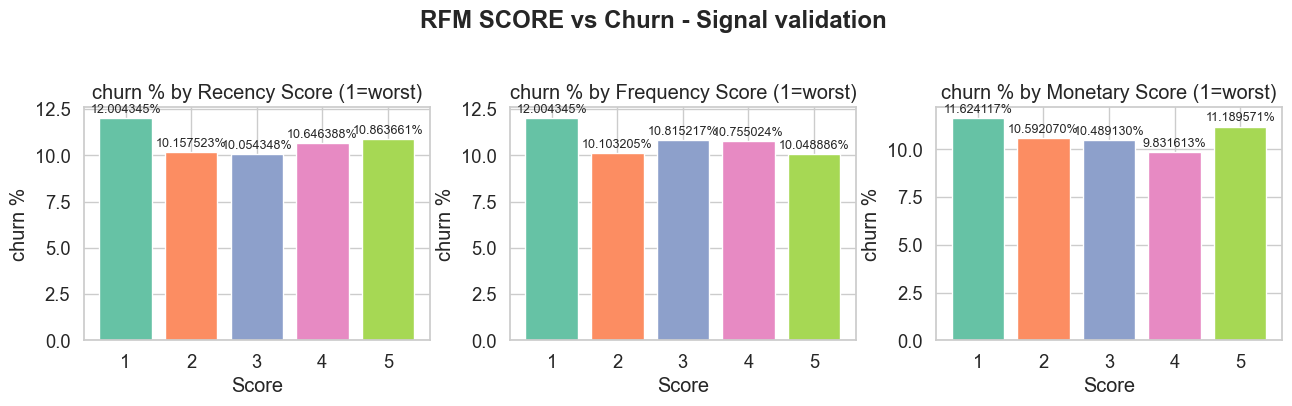

In [15]:
#### RFM + Churn + visualization (Signal)
# 1 - atleast 1 trip
# 2 - those account >= 60days

rfm_churn = rfm.merge(eligible, on="user_id", how="left")

fig, axes = plt.subplots(1,3, figsize=(13,4))

for ax , col, title in zip(
    axes,
    ["rfm_recency_score", "rfm_frequency_score", "rfm_monetary_score"],
    ["Recency", "Frequency", "Monetary"]
):
    data = rfm_churn.groupby(col)["churned"].mean().mul(100).reset_index()

    ax.bar(
        data[col].astype(str), data["churned"],
        color=sns.color_palette("Set2"), edgecolor="white"
    )

    ax.set(
        title=f"churn % by {title} Score (1=worst)",
        xlabel="Score", ylabel="churn %"
    )
    for _, row in data.iterrows():
        ax.text(row[col] - 1, row["churned"] + 0.3, f"{row["churned"]:1f}%", ha="center", fontsize=9)


plt.suptitle("RFM SCORE vs Churn - Signal validation", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Step 3- Behavioral Features 
- Capture how users engage, not just how much, when last or how often
- E.g two riders with 10 trips/month might have totally churn risk
- One of these 2 riders only commutes during rush hour VS randomly on a weekend
- The pattern matters as much 

In [16]:
trips.head(5)

,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,city,loyalty_status,trip_duration,total_revenue,hour_of_day,day_of_week
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 16:14:50,2024-11-27 17:06:50,-1.108123,36.912209,-1.068155,36.875377,Foggy,Nairobi,Bronze,52.0,12.11,16,Wednesday
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 22:59:48,2024-10-28 23:12:48,6.675266,3.515740,6.641734,3.525620,Sunny,Lagos,Gold,13.0,8.75,22,Monday
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 03:09:41,2025-02-17 03:25:41,-1.248589,37.010668,-1.273182,37.018586,Cloudy,Nairobi,Bronze,16.0,19.68,3,Monday
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 17:22:14,2024-06-18 17:27:14,29.819554,31.188780,29.837689,31.232978,Cloudy,Cairo,Bronze,5.0,16.44,17,Tuesday
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 07:31:16,2024-10-05 08:01:16,-1.676479,36.729219,-1.638395,36.694063,Sunny,Nairobi,Gold,30.0,9.76,7,Saturday


## Step 3a - Trips Pattern Features

In [17]:
# step 3a Peak hours 
PEAK_HOURS = list(range(7,10)) + list(range(17, 20))
PAYMENT_MAP = {"Card": 0, "Cash": 1, "Wallet": 2, "Corporate":3}


# 1 - define if a trip was during peak hour
# 2 - define if a trip was during the weekend
# 3 - define if a tip was on a rainy day

trips["is_peak"] = trips["hour_of_day"].isin(PEAK_HOURS).astype(int)
trips["is_weekend"] = trips["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
trips["is_rainy"] = (trips["weather"] == "Rainy").astype(int)


# Aggregate our trips dataset to derive more features
behavioral = (
    trips.groupby("user_id")
    .agg(

        # aggregated features
        avg_trip_duration=("trip_duration", "mean"),
        avg_fare=("fare", "mean"),
        avg_surge=("surge_multiplier", "mean"),
        tip_rate=("tip", lambda x:(x > 0).mean()),

        # Earlier engineered features 
        peak_hour_rate=("is_peak", "mean"),
        weekend_ratio=("is_weekend", "mean"),
        rainy_ride_ratio=("is_rainy", "mean")
    ).round(2).reset_index()
)

In [18]:
behavioral.head()

,user_id,avg_trip_duration,avg_fare,avg_surge,tip_rate,peak_hour_rate,weekend_ratio,rainy_ride_ratio
0,R00000,30.32,14.64,1.10,0.40,0.20,0.16,0.16
1,R00001,28.64,12.90,1.07,0.21,0.21,0.29,0.00
2,R00002,31.54,15.79,1.19,0.21,0.38,0.12,0.25
3,R00003,32.56,13.50,1.16,0.22,0.11,0.33,0.33
4,R00004,36.12,16.78,1.26,0.44,0.25,0.44,0.25


## Step 3b - Prefereed payment Engineering

In [19]:

# preferred payment (most frequent) is very important
# it tell us the stickeness level user usually at through wallet
# (mobile wallet featured) more invested in the platform than people paying using cash

payment_mode = (
    trips.groupby("user_id")["payment_type"]
    .agg(lambda x: x.mode().iloc[0]).reset_index()
)
# attach these payent method to payment map (encoded)
payment_mode["preffered_payment_encoded"] = (
    payment_mode["payment_type"].map(PAYMENT_MAP).fillna(0).astype(int))


# Merge all of these new info into Behavioral
behavioral = behavioral.merge(
    payment_mode[["user_id", "preffered_payment_encoded"]], on="user_id", how="left"
)

## Step 3c - Drivers Quality

In [20]:
# Step 3c(i) - for example is the average rating for driver is 4.5, driver that surpass
# TRIPS + DRIVERS + DRIVER RATING
trips_rated = trips.merge(
    drivers[["driver_id", "rating" ]], on="driver_id", how="left"
)

# Step 3c(ii) - we derived DRIVER-QUALITY-- group all drivers from "trip_rated" based on their ratings
driver_quality = (
    trips_rated.groupby("user_id")["rating"].mean()
    .reset_index(name="avg_driver_rating_received").round(3)
)


# step 3c(iii) - we merge driver's quality into the behavioral dataframe
behavioral = behavioral.merge(driver_quality, on="user_id", how="left")


# Step 3c (iv) - we engineer a new column Avergae drivers ratings received
behavioral["avg_driver_rating_received"] = (
    behavioral["avg_driver_rating_received"].fillna(behavioral["avg_driver_rating_received"].median())
)



## Step 3d - Session / Engagement Feature

In [21]:
# session Frequency windows
sessions.head()

,session_id,rider_id,session_time,time_on_app,pages_visited,converted,city,loyalty_status
0,S000000,R08605,2025-04-27 16:52:06,79,4,1,Cairo,Bronze
1,S000001,R08823,2025-04-27 05:05:22,101,3,0,Nairobi,Silver
2,S000002,R05342,2025-04-27 21:12:25,12,1,0,Cairo,Bronze
3,S000003,R05057,2025-04-27 14:26:25,19,1,0,Lagos,Silver
4,S000004,R09614,2025-04-27 08:17:22,4,1,0,Lagos,Bronze


In [22]:
# Session frequency window
sess_freq = pd.DataFrame({"user_id": sessions["rider_id"].unique()})

# loops to iterate over the sessions
# Cutoff for 30days
for days in [30, 60]:
    cutoff = reference_date - pd.Timedelta(days=days)
    counts = (
        sessions[ sessions["session_time"] >= cutoff]
        .groupby("rider_id").size()
        .reset_index(name=f"session_last_{days}d")
        .rename(columns={"rider_id": "user_id"})
    )
    sess_freq = sess_freq.merge(counts, on="user_id", how="left")

# cleaning of the new columns
sess_freq[[ "session_last_30d", "session_last_60d" ]] = (
    sess_freq[[ "session_last_30d", "session_last_60d" ]].fillna(0).astype(int)
)



# Engagement depth
engagement = (
    sessions.groupby("rider_id")
    .agg(
        avg_time_on_app=("time_on_app", "mean"),
        avg_pages_visited=("pages_visited", "mean"),
        session_conversation_rate=("converted", "mean"),
    )
    .round(2).reset_index()
    .rename(columns={"rider_id" : "user_id"})
)

# Engagement score
engagement["engagement_score"] = (
    engagement["avg_time_on_app"] * engagement["avg_pages_visited"]
).round(2)

sess_freq = sess_freq.merge(engagement, on="user_id", how="left")


In [23]:
eligible.head()

,user_id,churned
0,R00000,0
1,R00001,1
2,R00002,1
4,R00004,0
5,R00005,0


## Step 4 - Temporal Features 

#### time-based features 
 - Activity Trend --- is the user becoming more active or less active recently 
 - Unique Active days --- How many different days has the user actually ridden for


In [24]:
# Activity Trend 
# Is this rider slipping away from us 
# last 30days or 60days ----- is the use becoming more active or less

# E.g Esther : 15 trips in the last month (30days) ----- 12 trips the month before (60days)
# is she more active(growing) or less (declining) 
# 12 --- 15

# E.g samule : 3 trips (30days)--- 12 trips the month before
#Declining)

# cutoff_30  = reference_date - pd.Timedleta(days=30)
# cutoff_60  = reference_date - pd.Timedleta(days=60)

# Imagine today is may 31 2026 (reference date)

# feb 1                   march 1             march 31st (today)
#  Day 60                   Day 30                   Day 0

# prior 30d    | recent 30d
# (feb 1 - feb 29) | (mar 1 - mar 31)






temporal = riders[riders["user_id"].isin(eligible["user_id"])][
    ["user_id", "account_age_days"]
].copy()


# Activity trend 1 : trips in the last 30day/60day vs prior 30d or 60day
cutoff_30 = reference_date -  pd.Timedelta(days=30)
cutoff_60 = reference_date - pd.Timedelta(days=60)

recent = (
    trips[ trips["pickup_time"] >= cutoff_30   ]
    .groupby("user_id").size().reset_index(name="_r30")
)

prior = (
    trips[ (trips["pickup_time"] >= cutoff_60) &   (trips["pickup_time"] < cutoff_30) ]
.groupby("user_id").size().reset_index(name="_p30")
)

# merge recnt & prior into temporal
temporal = (
    temporal
    .merge(recent, on="user_id", how="left")
    .merge(prior, on="user_id", how="left")
)

# temporal cleaning 
temporal[["_r30", "_p30"]] = temporal[["_r30", "_p30"]].fillna(0)

# determine activity trend the last 30days
temporal["activity_trend_30d"] = ( temporal["_r30"] / (temporal["_r30"] + 1)).round(2)
temporal = temporal.drop(columns=["_r30", "_p30"])




#  + Unique days

# how manay different days has this rider actually used the app
trips["trip_date"] = trips["pickup_time"].dt.date
unique_days = (
    trips.groupby("user_id")["trip_date"].nunique()
    .reset_index(name="unique_active_days")
)

# merge back to the temporal dataset
temporal = temporal.merge(unique_days, on="user_id", how="left")
temporal["unique_active_days"] = temporal["unique_active_days"].fillna(0).astype(int)